In [3]:
import pandas as pd
import numpy as np

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

In [10]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [11]:
print("Total rows:", len(nav))
print("Missing daily returns:", nav["daily_return"].isna().sum())

Total rows: 46000
Missing daily returns: 40


## Task 1: Historical VaR (95%) and CVaR

In [12]:
risk_list = []

In [13]:
for fund in nav["amfi_code"].unique():

    # select one fund
    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    # get daily returns
    returns = fund_data["daily_return"].dropna()

    # calculate VaR
    var95 = returns.quantile(0.05)

    # calculate CVaR
    cvar95 = returns[
        returns <= var95
    ].mean()

    # store the result
    risk_list.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

In [14]:
var_table = pd.DataFrame(risk_list)

var_table.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
var_table["VaR_pct"] = var_table["VaR_95"] * 100
var_table["CVaR_pct"] = var_table["CVaR_95"] * 100

var_table.head()

,amfi_code,VaR_95,CVaR_95,VaR_pct,CVaR_pct
0,100016,-0.014364,-0.018060,-1.436364,-1.806021
1,100025,-0.003793,-0.004994,-0.379325,-0.499376
2,100033,-0.019034,-0.023456,-1.903354,-2.345576
3,101206,-0.013282,-0.017439,-1.328166,-1.743943
4,101207,-0.026021,-0.032459,-2.602125,-3.245906


In [16]:
var_table = var_table.sort_values(
    by="VaR_95",
    ascending=True
)

var_table.reset_index(
    drop=True,
    inplace=True
)

var_table.head(10)

,amfi_code,VaR_95,CVaR_95,VaR_pct,CVaR_pct
0,119599,-0.026859,-0.032384,-2.685944,-3.238412
1,119095,-0.026188,-0.031667,-2.618842,-3.166729
2,101207,-0.026021,-0.032459,-2.602125,-3.245906
3,118634,-0.025438,-0.032304,-2.543811,-3.230407
4,119598,-0.024507,-0.030595,-2.450705,-3.059526
5,149324,-0.023483,-0.031036,-2.348307,-3.103625
6,102886,-0.019220,-0.023251,-1.922028,-2.325086
7,100033,-0.019034,-0.023456,-1.903354,-2.345576
8,120505,-0.018892,-0.024342,-1.889179,-2.434207
9,119094,-0.018480,-0.024260,-1.848028,-2.426006


In [17]:
print("Number of funds:", len(var_table))
print("Missing VaR:", var_table["VaR_95"].isna().sum())
print("Missing CVaR:", var_table["CVaR_95"].isna().sum())

Number of funds: 40
Missing VaR: 0
Missing CVaR: 0


In [18]:
var_table.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully.")

var_cvar_report.csv saved successfully.


### Observation

- Historical VaR (95%) was calculated for all 40 mutual fund schemes.
- CVaR was calculated using returns below the VaR threshold.
- Funds with more negative VaR values have higher downside risk.
- CVaR shows the average loss during the worst 5% of trading days.
- The analysis helps compare downside risk across different mutual fund schemes.

## Task 2: Rolling 90-Day Sharpe Ratio

In [19]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            / x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

In [20]:
nav[
    ["amfi_code", "date", "daily_return", "rolling_sharpe"]
].head(100)

,amfi_code,date,daily_return,rolling_sharpe
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,NaN
2,100016,2022-01-05,0.012865,NaN
3,100016,2022-01-06,-0.011377,NaN
4,100016,2022-01-07,-0.001210,NaN
...,...,...,...,...
95,100016,2022-05-16,-0.004283,-0.419782
96,100016,2022-05-17,0.026682,-0.029988
97,100016,2022-05-18,-0.008220,-0.132298
98,100016,2022-05-19,-0.007582,-0.194050


In [21]:
print(
    "Rolling Sharpe column created:",
    "rolling_sharpe" in nav.columns
)

print(
    "Missing rolling Sharpe:",
    nav["rolling_sharpe"].isna().sum()
)

Rolling Sharpe column created: True
Missing rolling Sharpe: 3600


In [22]:
top5_codes = [
    119551,
    120503,
    118632,
    119092,
    120841
]

In [23]:
import matplotlib.pyplot as plt

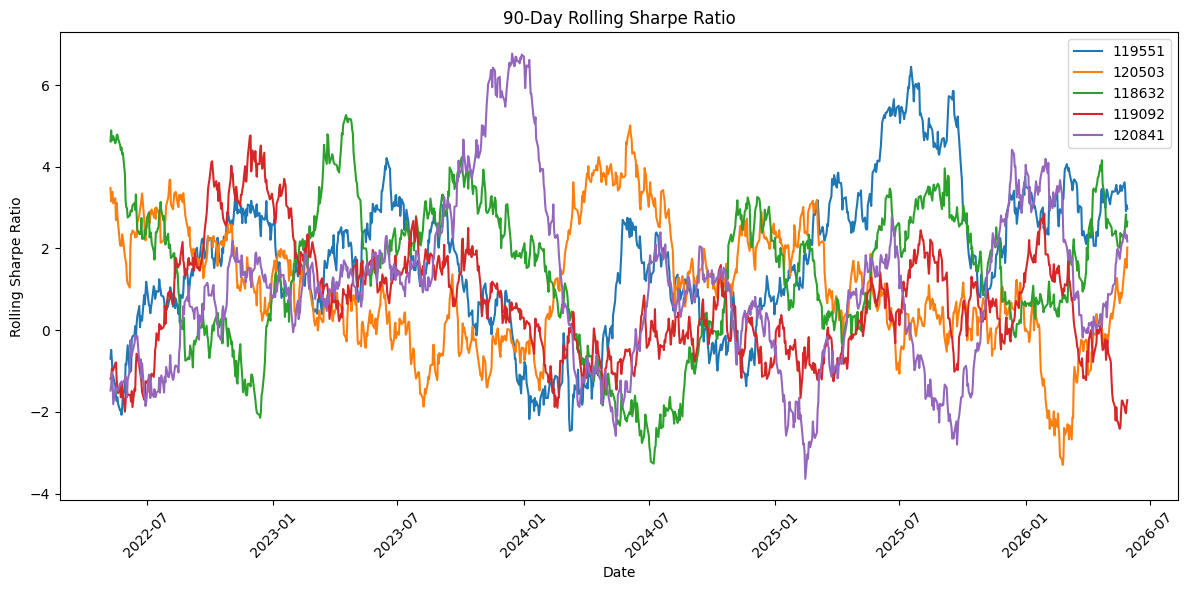

In [24]:
plt.figure(figsize=(12, 6))

for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.title("90-Day Rolling Sharpe Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

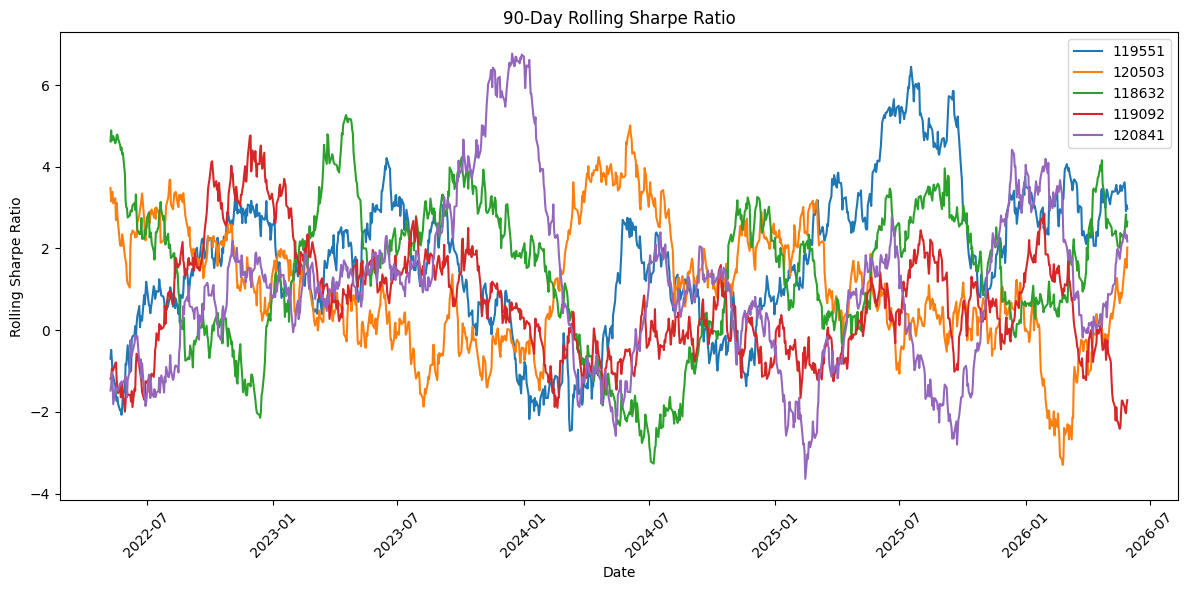

In [25]:
plt.figure(figsize=(12, 6))

for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.title("90-Day Rolling Sharpe Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [26]:
for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    print(
        fund,
        "Latest Rolling Sharpe:",
        fund_data["rolling_sharpe"].dropna().iloc[-1]
    )

119551 Latest Rolling Sharpe: 2.9722350513305154
120503 Latest Rolling Sharpe: 2.0236152330038135
118632 Latest Rolling Sharpe: 2.6505235791942376
119092 Latest Rolling Sharpe: -1.7152055163641473
120841 Latest Rolling Sharpe: 2.167518120865084


In [27]:
import os

print("Chart exists:", os.path.exists("../reports/rolling_sharpe_chart.png"))

Chart exists: True


### Observation

- A 90-day rolling Sharpe ratio was calculated for all 40 mutual fund schemes.
- The rolling Sharpe ratio shows how risk-adjusted performance changed over time.
- Five key funds were selected for comparison.
- Higher Sharpe values indicate better return relative to the volatility taken.
- The rolling chart helps identify periods of stronger and weaker risk-adjusted performance.

## Task 3: Investor Cohort Analysis

In [28]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

In [29]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [30]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [31]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [32]:
transactions["transaction_year"] = (
    transactions["transaction_date"].dt.year
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [33]:
first_transaction = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [34]:
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [35]:
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [36]:
sip_data = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

avg_sip = (
    sip_data.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={"amount_inr": "avg_sip_amount"},
    inplace=True
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [37]:
investment_data = transactions[
    transactions["transaction_type"].isin(
        ["SIP", "Lumpsum"]
    )
].copy()

total_invested = (
    investment_data.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_invested.rename(
    columns={"amount_inr": "total_invested"},
    inplace=True
)

total_invested

,cohort_year,total_invested
0,2024,2258062304
1,2025,18992635


In [38]:
fund_count = (
    investment_data.groupby(
        ["cohort_year", "amfi_code"]
    ).size()
    .reset_index(name="transaction_count")
)

top_fund = (
    fund_count.sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,transaction_count
33,2024,125498,752
62,2025,119599,11


In [39]:
cohort_table = avg_sip.merge(
    total_invested,
    on="cohort_year",
    how="outer"
)

cohort_table = cohort_table.merge(
    top_fund[
        ["cohort_year", "amfi_code", "transaction_count"]
    ],
    on="cohort_year",
    how="outer"
)

cohort_table

,cohort_year,avg_sip_amount,total_invested,amfi_code,transaction_count
0,2024,10996.885825,2258062304,125498,752
1,2025,13505.209581,18992635,119599,11


In [40]:
cohort_table.rename(
    columns={
        "amfi_code": "top_fund"
    },
    inplace=True
)

cohort_table

,cohort_year,avg_sip_amount,total_invested,top_fund,transaction_count
0,2024,10996.885825,2258062304,125498,752
1,2025,13505.209581,18992635,119599,11


In [41]:
cohort_table = cohort_table.sort_values(
    "cohort_year"
).reset_index(drop=True)

cohort_table

,cohort_year,avg_sip_amount,total_invested,top_fund,transaction_count
0,2024,10996.885825,2258062304,125498,752
1,2025,13505.209581,18992635,119599,11


In [42]:
print("Cohort years:")
print(sorted(transactions["cohort_year"].unique()))

print(
    "Number of investors:",
    transactions["investor_id"].nunique()
)

Cohort years:
[np.int32(2024), np.int32(2025)]
Number of investors: 5000


In [43]:
print(
    "First transaction date:",
    transactions["transaction_date"].min()
)

print(
    "Last transaction date:",
    transactions["transaction_date"].max()
)

First transaction date: 2024-01-01 00:00:00
Last transaction date: 2025-05-30 00:00:00


In [44]:
cohort_table.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("investor_cohort_analysis.csv saved successfully.")

investor_cohort_analysis.csv saved successfully.


### Observation

- Investors were grouped into cohorts based on their first transaction year.
- The average SIP amount was calculated for each investor cohort.
- Total invested amount was calculated using SIP and Lumpsum transactions.
- The most preferred fund in each cohort was identified using transaction count.
- The cohort analysis helps compare investment behaviour across different groups of investors.

## Task 4: SIP Continuity Analysis

In [45]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [46]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [47]:
sip_data = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_data = sip_data.sort_values(
    ["investor_id", "transaction_date"]
)

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


In [48]:
sip_counts = (
    sip_data.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

sip_counts.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [49]:
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

print(
    "Investors with 6 or more SIPs:",
    len(eligible_investors)
)

Investors with 6 or more SIPs: 1362


In [50]:
sip_data["gap_days"] = (
    sip_data.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_data.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,28.0


In [51]:
avg_gap = (
    sip_data.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index()
)

avg_gap.rename(
    columns={"gap_days": "avg_gap_days"},
    inplace=True
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [52]:
sip_continuity = eligible_investors.merge(
    avg_gap,
    on="investor_id",
    how="left"
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [53]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days,status
0,INV000004,6,85.400000,At-Risk
1,INV000008,6,70.400000,At-Risk
2,INV000010,6,64.800000,At-Risk
3,INV000011,7,40.166667,At-Risk
4,INV000012,8,57.000000,At-Risk
5,INV000013,7,55.333333,At-Risk
6,INV000014,7,75.333333,At-Risk
7,INV000023,8,58.571429,At-Risk
8,INV000028,6,93.600000,At-Risk
9,INV000029,7,60.666667,At-Risk


In [54]:
print(
    "Total eligible investors:",
    len(sip_continuity)
)

print(
    "At-Risk investors:",
    (sip_continuity["status"] == "At-Risk").sum()
)

print(
    "Regular investors:",
    (sip_continuity["status"] == "Regular").sum()
)

Total eligible investors: 1362
At-Risk investors: 1332
Regular investors: 30


In [55]:
continuity_rate = (
    (sip_continuity["status"] == "Regular").sum()
    / len(sip_continuity)
) * 100

print(
    "SIP Continuity Rate:",
    round(continuity_rate, 2),
    "%"
)

SIP Continuity Rate: 2.2 %


In [56]:
sip_continuity.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("sip_continuity_analysis.csv saved successfully.")

sip_continuity_analysis.csv saved successfully.


### Observation

- SIP continuity was analyzed for investors with at least 6 SIP transactions.
- 1,362 investors met the minimum SIP transaction requirement.
- 1,332 investors were classified as At-Risk because their average SIP gap was more than 35 days.
- 30 investors were classified as Regular based on the 35-day gap rule.
- The SIP continuity rate was approximately 2.2%.
- The analysis indicates that most eligible investors had irregular SIP transaction intervals.

## Task 5: Simple Fund Recommender

In [57]:
scheme_performance = pd.read_csv(
    "../data/processed/09_scheme_performance.csv"
)

scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [58]:
scheme_performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [59]:
scheme_performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [1]:
risk_map = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

selected_grades = risk_map[risk_appetite]

recommended_funds = scheme_performance[
    scheme_performance["risk_grade"].isin(selected_grades)
].copy()

recommended_funds.head()

NameError: name 'risk_appetite' is not defined

In [2]:
import pandas as pd

scheme_performance = pd.read_csv(
    "../data/processed/09_scheme_performance.csv"
)

print("Rows:", len(scheme_performance))

Rows: 40


In [3]:
risk_appetite = "Moderate"

print("Selected risk appetite:", risk_appetite)

Selected risk appetite: Moderate


In [4]:
risk_map = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

selected_grades = risk_map[risk_appetite]

print("Risk grades used:", selected_grades)

Risk grades used: ['Moderate', 'Moderately High']


In [5]:
recommended_funds = scheme_performance[
    scheme_performance["risk_grade"].isin(selected_grades)
].copy()

recommended_funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate


In [6]:
recommended_funds = recommended_funds.sort_values(
    by="sharpe_ratio",
    ascending=False
)

recommended_funds.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,1.03,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,Regular,16.67,14.76,12.60,14.21,0.55,0.92,0.98,1.50,15.0,-21.89,2571,1.41,4,Moderately High
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,1.00,0.96,1.37,16.0,-12.14,17912,1.64,5,Moderately High
31,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Index,Regular,13.76,12.10,11.31,11.17,0.93,0.90,0.93,1.29,13.0,-24.42,7350,1.57,4,Moderate


In [7]:
top_3_funds = recommended_funds.head(3)

top_3_funds[
    [
        "amfi_code",
        "scheme_name",
        "risk_grade",
        "sharpe_ratio"
    ]
]

,amfi_code,scheme_name,risk_grade,sharpe_ratio
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [8]:
recommendation_table = top_3_funds[
    [
        "amfi_code",
        "scheme_name",
        "risk_grade",
        "sharpe_ratio"
    ]
].copy()

recommendation_table

,amfi_code,scheme_name,risk_grade,sharpe_ratio
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [9]:
recommendation_table.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("fund_recommendations.csv saved successfully.")

fund_recommendations.csv saved successfully.


### Observation

- A simple fund recommender was created based on the selected risk appetite.
- Moderate risk included Moderate and Moderately High risk grades.
- Funds were ranked using Sharpe ratio.
- HDFC Top 100 Fund, Mirae Asset Large Cap Fund and ICICI Pru Bluechip Fund were the top three recommendations for Moderate risk.
- Higher Sharpe ratio indicates better risk-adjusted performance.

## Task 6: Sector HHI Concentration

In [10]:
import pandas as pd

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [11]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [12]:
holdings[['amfi_code', 'sector', 'weight_pct']].head(10)

,amfi_code,sector,weight_pct
0,119551,Utilities,13.85
1,119551,Banking,11.19
2,119551,Diversified,9.90
3,119551,Pharma,4.76
4,119551,Paints,10.25
5,119551,Utilities,7.48
6,119551,Pharma,3.21
7,119551,Telecom,13.94
8,119551,IT,18.22
9,119551,Automobile,7.20


In [13]:
holdings[['amfi_code', 'sector', 'weight_pct']].isna().sum()

amfi_code     0
sector        0
weight_pct    0
dtype: int64

In [14]:
holdings.groupby('amfi_code')['weight_pct'].sum().head(10)

amfi_code
100016    100.00
100033    100.00
101206    100.01
101207     99.99
102885    100.00
102886     99.98
102887    100.01
118632    100.02
118633    100.00
118634    100.00
Name: weight_pct, dtype: float64

In [15]:
sector_weights = (
    holdings.groupby(['amfi_code', 'sector'])['weight_pct']
    .sum()
    .reset_index()
)

sector_weights.head(10)

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90
5,100016,NBFC,7.01
6,100016,Pharma,25.48
7,100016,Utilities,5.61
8,100033,Automobile,26.07
9,100033,Banking,35.97


In [18]:
sector_weights['weight_decimal'] = sector_weights['weight_pct'] / 100

hhi_table = (
    sector_weights
    .groupby('amfi_code')['weight_decimal']
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name='sector_hhi')
)

hhi_table.head(10)

,amfi_code,sector_hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712
5,102886,0.124020
6,102887,0.251383
7,118632,0.207259
8,118633,0.221200
9,118634,0.160299


In [17]:
hhi_table['sector_hhi'].describe()

count    34.000000
mean      0.202929
std       0.038622
min       0.124020
25%       0.180179
50%       0.204254
75%       0.230510
max       0.296769
Name: sector_hhi, dtype: float64

In [19]:
def concentration_level(hhi):
    if hhi < 0.15:
        return "Low"
    elif hhi < 0.25:
        return "Moderate"
    else:
        return "High"


hhi_table['concentration_level'] = hhi_table['sector_hhi'].apply(
    concentration_level
)

hhi_table.head(10)

,amfi_code,sector_hhi,concentration_level
0,100016,0.180588,Moderate
1,100033,0.227647,Moderate
2,101206,0.180042,Moderate
3,101207,0.222727,Moderate
4,102885,0.180712,Moderate
5,102886,0.124020,Low
6,102887,0.251383,High
7,118632,0.207259,Moderate
8,118633,0.221200,Moderate
9,118634,0.160299,Moderate


In [20]:
hhi_table = hhi_table.sort_values(
    'sector_hhi',
    ascending=False
).reset_index(drop=True)

hhi_table.head(10)

,amfi_code,sector_hhi,concentration_level
0,119092,0.296769,High
1,148569,0.254992,High
2,125498,0.253155,High
3,102887,0.251383,High
4,149323,0.241077,Moderate
5,120505,0.238695,Moderate
6,118635,0.237497,Moderate
7,119599,0.232361,Moderate
8,120506,0.231464,Moderate
9,100033,0.227647,Moderate


In [21]:
hhi_table['concentration_level'].value_counts()

concentration_level
Moderate    27
High         4
Low          3
Name: count, dtype: int64

## Task 6: Sector HHI Concentration

Sector concentration was measured using the Herfindahl-Hirschman Index (HHI), calculated as the sum of squared sector weights for each mutual fund.

- Total funds with holdings data: 34
- Low concentration: 3 funds
- Moderate concentration: 27 funds
- High concentration: 4 funds
- Average HHI: 0.2029
- Minimum HHI: 0.1240
- Maximum HHI: 0.2968

Most funds showed moderate sector concentration, while four funds had high concentration. Lower HHI values indicate better sector diversification, while higher values indicate greater concentration.

In [22]:
hhi_table.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

hhi_table.head()

,amfi_code,sector_hhi,concentration_level
0,119092,0.296769,High
1,148569,0.254992,High
2,125498,0.253155,High
3,102887,0.251383,High
4,149323,0.241077,Moderate


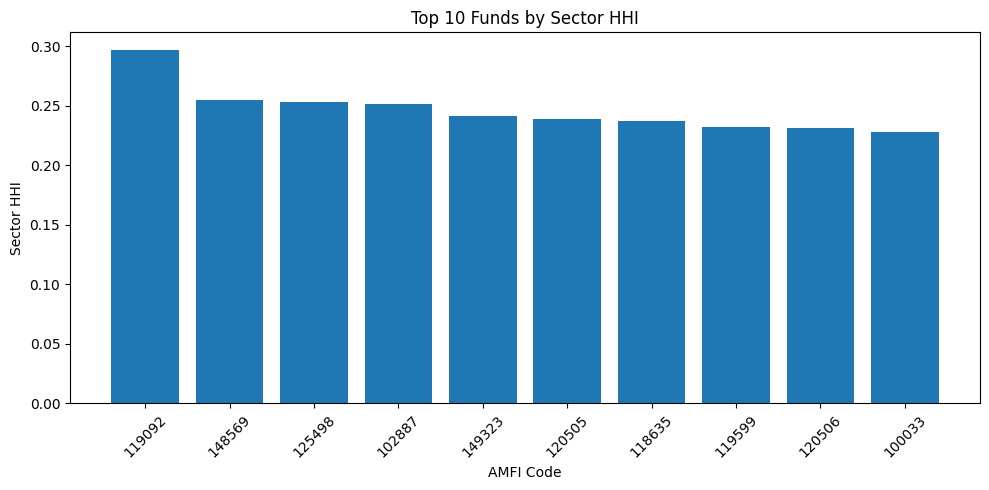

In [23]:
import matplotlib.pyplot as plt

top10_hhi = hhi_table.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top10_hhi['amfi_code'].astype(str),
    top10_hhi['sector_hhi']
)

plt.title("Top 10 Funds by Sector HHI")
plt.xlabel("AMFI Code")
plt.ylabel("Sector HHI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 7: Fund Risk-Adjusted Ranking

In [24]:
import pandas as pd

performance = pd.read_csv(
    "../data/processed/09_scheme_performance.csv"
)

hhi = pd.read_csv(
    "../data/processed/sector_hhi.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [25]:
hhi.columns

Index(['amfi_code', 'sector_hhi', 'concentration_level'], dtype='object')

In [26]:
ranking = performance.merge(
    hhi[['amfi_code', 'sector_hhi']],
    on='amfi_code',
    how='left'
)

ranking.shape

(40, 20)

In [27]:
ranking['return_rank'] = ranking['return_3yr_pct'].rank(
    ascending=False
)

ranking['sharpe_rank'] = ranking['sharpe_ratio'].rank(
    ascending=False
)

ranking['sortino_rank'] = ranking['sortino_ratio'].rank(
    ascending=False
)

ranking['alpha_rank'] = ranking['alpha'].rank(
    ascending=False
)

ranking['drawdown_rank'] = ranking['max_drawdown_pct'].rank(
    ascending=False
)

ranking['expense_rank'] = ranking['expense_ratio_pct'].rank(
    ascending=True
)

ranking['hhi_rank'] = ranking['sector_hhi'].rank(
    ascending=True
)

ranking.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,morningstar_rating,risk_grade,sector_hhi,return_rank,sharpe_rank,sortino_rank,alpha_rank,drawdown_rank,expense_rank,hhi_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,4,Moderate,0.142491,26.0,26.5,28.0,32.0,21.5,30.5,3.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,3,Moderate,0.227508,34.0,35.5,28.0,9.0,29.0,4.0,24.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,5,Very High,0.188085,1.0,18.0,25.0,20.0,8.0,21.0,15.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,4,Very High,0.232361,2.0,19.5,9.0,22.5,30.0,5.5,27.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,5,Low,NaN,38.0,5.0,6.0,13.0,2.0,9.0,NaN


In [28]:
ranking['risk_adjusted_score'] = (
    ranking['return_rank'] * 0.20 +
    ranking['sharpe_rank'] * 0.20 +
    ranking['sortino_rank'] * 0.15 +
    ranking['alpha_rank'] * 0.15 +
    ranking['drawdown_rank'] * 0.10 +
    ranking['expense_rank'] * 0.10 +
    ranking['hhi_rank'] * 0.10
)

In [29]:
final_ranking = (
    ranking
    .sort_values('risk_adjusted_score')
    .reset_index(drop=True)
)

final_ranking['rank'] = final_ranking.index + 1

final_ranking[
    [
        'rank',
        'amfi_code',
        'scheme_name',
        'category',
        'plan',
        'return_3yr_pct',
        'sharpe_ratio',
        'sortino_ratio',
        'alpha',
        'max_drawdown_pct',
        'sector_hhi',
        'risk_adjusted_score'
    ]
].head(10)

,rank,amfi_code,scheme_name,category,plan,return_3yr_pct,sharpe_ratio,sortino_ratio,alpha,max_drawdown_pct,sector_hhi,risk_adjusted_score
0,1,120843,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,Regular,15.65,0.98,1.57,1.85,-19.50,0.136206,11.325
1,2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,Regular,14.81,1.06,1.66,1.62,-17.07,0.201248,13.700
2,3,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,Regular,23.39,0.94,1.35,1.23,-13.35,0.188085,14.950
3,4,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Direct,23.14,0.93,1.67,1.13,-24.78,0.232361,15.275
4,5,120842,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,Regular,18.23,0.96,1.27,1.91,-21.92,0.162062,15.675
5,6,101207,ABSL Small Cap Fund - Regular - Growth,Small Cap,Regular,22.38,0.90,1.47,1.84,-23.61,0.222727,16.800
6,7,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,Regular,14.84,1.06,1.70,0.78,-17.41,0.180588,16.900
7,8,118632,Nippon India Large Cap Fund - Regular - Growth,Large Cap,Regular,14.00,1.00,1.68,0.86,-16.07,0.207259,17.900
8,9,102887,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,Regular,15.34,0.96,1.37,1.79,-12.14,0.251383,18.150
9,10,149322,DSP Top 100 Equity Fund - Regular - Growth,Large Cap,Regular,12.82,0.92,1.63,1.82,-21.70,0.182695,18.250


In [30]:
final_ranking.to_csv(
    "../data/processed/fund_risk_adjusted_ranking.csv",
    index=False
)

print("Final ranking saved successfully.")

Final ranking saved successfully.


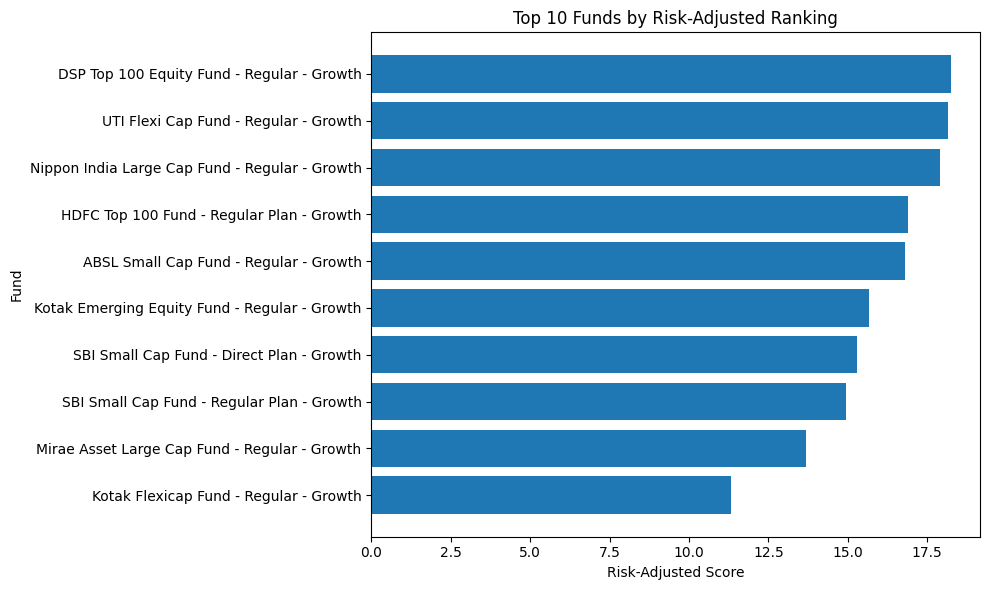

In [31]:
import matplotlib.pyplot as plt

top10 = final_ranking.head(10).sort_values(
    'risk_adjusted_score',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['scheme_name'],
    top10['risk_adjusted_score']
)

plt.xlabel("Risk-Adjusted Score")
plt.ylabel("Fund")
plt.title("Top 10 Funds by Risk-Adjusted Ranking")
plt.tight_layout()
plt.show()

## Task 7: Fund Risk-Adjusted Ranking

A composite risk-adjusted score was created using 3-year return, Sharpe ratio, Sortino ratio, alpha, maximum drawdown, expense ratio, and sector HHI.

The metrics were converted into ranks and combined using weighted scoring. A lower score indicates better overall performance and risk characteristics.

The top-ranked fund was Kotak Flexicap Fund - Regular - Growth, followed by Mirae Asset Large Cap Fund - Regular - Growth and SBI Small Cap Fund - Regular Plan - Growth.

The final ranking was saved as `fund_risk_adjusted_ranking.csv`.

## Task 8: Fund Risk-Return Analysis

In [32]:
import pandas as pd

ranking = pd.read_csv(
    "../data/processed/fund_risk_adjusted_ranking.csv"
)

ranking.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sector_hhi,return_rank,sharpe_rank,sortino_rank,alpha_rank,drawdown_rank,expense_rank,hhi_rank,risk_adjusted_score,rank
0,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,0.136206,11.0,12.0,12.0,3.5,20.0,22.0,2.0,11.325,1
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,0.201248,17.0,7.5,10.0,12.0,15.0,23.0,17.0,13.700,2
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.188085,1.0,18.0,25.0,20.0,8.0,21.0,15.0,14.950,3
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.232361,2.0,19.5,9.0,22.5,30.0,5.5,27.0,15.275,4
4,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,0.162062,7.0,15.0,30.5,2.0,25.0,33.0,6.0,15.675,5


In [33]:
ranking.shape

(40, 29)

In [34]:
ranking.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'sector_hhi', 'return_rank',
       'sharpe_rank', 'sortino_rank', 'alpha_rank', 'drawdown_rank',
       'expense_rank', 'hhi_rank', 'risk_adjusted_score', 'rank'],
      dtype='object')

In [35]:
ranking[
    [
        'return_3yr_pct',
        'sharpe_ratio',
        'std_dev_ann_pct',
        'max_drawdown_pct',
        'risk_adjusted_score'
    ]
].describe()

,return_3yr_pct,sharpe_ratio,std_dev_ann_pct,max_drawdown_pct,risk_adjusted_score
count,40.000000,40.000000,40.000000,40.000000,34.000000
mean,14.089000,1.361750,14.962500,-19.200250,21.395588
std,4.617253,1.475805,6.669282,8.819164,5.036415
min,5.140000,0.800000,0.500000,-33.500000,11.325000
25%,12.035000,0.865000,14.000000,-25.062500,18.175000
50%,14.205000,0.925000,14.000000,-20.600000,20.287500
75%,15.882500,0.985000,19.000000,-14.255000,25.112500
max,23.390000,7.680000,25.000000,-2.230000,33.700000


In [37]:
best_fund = ranking.loc[
    ranking['risk_adjusted_score'].idxmin(),
    ['scheme_name', 'return_3yr_pct', 'sharpe_ratio',
     'std_dev_ann_pct', 'max_drawdown_pct', 'risk_adjusted_score']
]

worst_fund = ranking.loc[
    ranking['risk_adjusted_score'].idxmax(),
    ['scheme_name', 'return_3yr_pct', 'sharpe_ratio',
     'std_dev_ann_pct', 'max_drawdown_pct', 'risk_adjusted_score']
]

print("Best Fund:")
print(best_fund)

print("\nWorst Fund:")
print(worst_fund)

Best Fund:
scheme_name            Kotak Flexicap Fund - Regular - Growth
return_3yr_pct                                          15.65
sharpe_ratio                                             0.98
std_dev_ann_pct                                          16.0
max_drawdown_pct                                        -19.5
risk_adjusted_score                                    11.325
Name: 0, dtype: object

Worst Fund:
scheme_name            Mirae Asset Tax Saver Fund - Regular - Growth
return_3yr_pct                                                 13.58
sharpe_ratio                                                     0.8
std_dev_ann_pct                                                 17.0
max_drawdown_pct                                              -22.62
risk_adjusted_score                                             33.7
Name: 33, dtype: object


In [38]:
risk_return_corr = ranking[
    [
        'return_3yr_pct',
        'sharpe_ratio',
        'std_dev_ann_pct',
        'max_drawdown_pct'
    ]
].corr()

risk_return_corr

,return_3yr_pct,sharpe_ratio,std_dev_ann_pct,max_drawdown_pct
return_3yr_pct,1.000000,-0.519123,0.956132,-0.479871
sharpe_ratio,-0.519123,1.000000,-0.679069,0.577159
std_dev_ann_pct,0.956132,-0.679069,1.000000,-0.594780
max_drawdown_pct,-0.479871,0.577159,-0.594780,1.000000


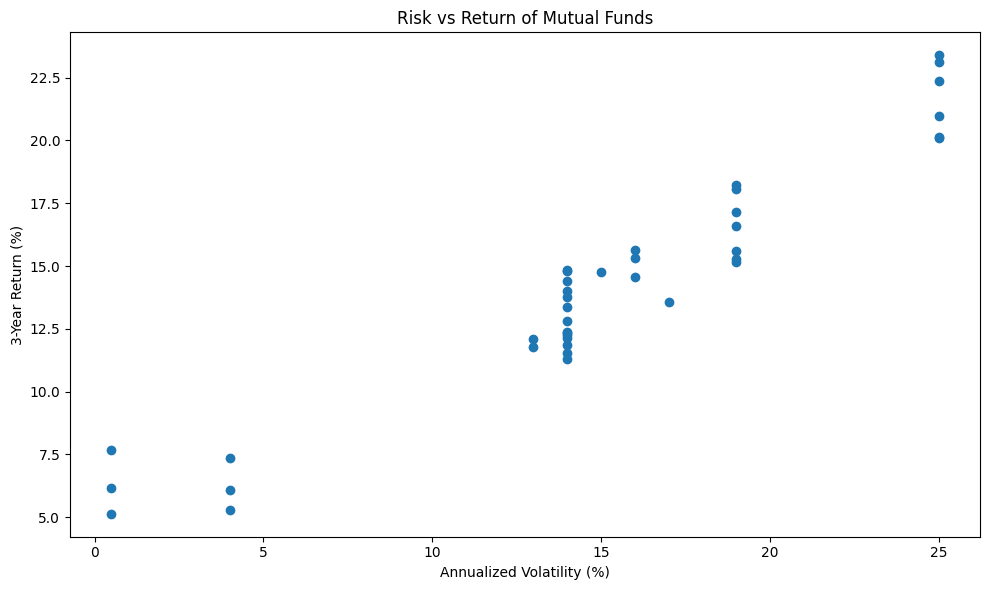

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    ranking['std_dev_ann_pct'],
    ranking['return_3yr_pct']
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("3-Year Return (%)")
plt.title("Risk vs Return of Mutual Funds")
plt.tight_layout()
plt.show()

In [40]:
top_sharpe = ranking.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

top_sharpe[
    ['scheme_name', 'sharpe_ratio', 'return_3yr_pct', 'std_dev_ann_pct']
]

,scheme_name,sharpe_ratio,return_3yr_pct,std_dev_ann_pct
36,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68,0.5
38,Kotak Liquid Fund - Regular - Growth,6.18,6.18,0.5
39,ABSL Liquid Fund - Regular - Growth,5.14,5.14,0.5
35,HDFC Short Term Debt Fund - Regular - Growth,1.84,7.37,4.0
34,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,6.07,4.0
37,Nippon India Gilt Securities Fund - Regular - ...,1.33,5.31,4.0
1,Mirae Asset Large Cap Fund - Regular - Growth,1.06,14.81,14.0
6,HDFC Top 100 Fund - Regular Plan - Growth,1.06,14.84,14.0
20,ICICI Pru Bluechip Fund - Direct - Growth,1.03,14.41,14.0
7,Nippon India Large Cap Fund - Regular - Growth,1.00,14.00,14.0


In [41]:
ranking.to_csv(
    "../data/processed/fund_risk_return_analysis.csv",
    index=False
)

print("Task 8 data saved successfully.")

Task 8 data saved successfully.


## Task 8: Fund Risk-Return Analysis

The risk-return analysis compared 3-year returns with volatility, Sharpe ratio, and maximum drawdown across 40 mutual fund schemes.

The average 3-year return was 14.09%, while the average annualized volatility was 14.96%. The average maximum drawdown was -19.20%.

Kotak Flexicap Fund - Regular - Growth achieved the best overall risk-adjusted score of 11.325. It had a 3-year return of 15.65%, Sharpe ratio of 0.98, annualized volatility of 16.0%, and maximum drawdown of -19.50%.

Mirae Asset Tax Saver Fund - Regular - Growth had the lowest overall ranking score, with a score of 33.70.

The correlation analysis showed a strong positive relationship between 3-year return and volatility, with a correlation of 0.956. This indicates that higher-return funds in this dataset generally experienced higher volatility.

The analysis also showed a negative correlation of -0.679 between Sharpe ratio and volatility, indicating that higher Sharpe ratios were generally associated with lower volatility in this dataset.

## Task 9: Fund Performance vs Benchmark

In [42]:
benchmark_analysis = ranking.copy()

benchmark_analysis['benchmark_difference_pct'] = (
    benchmark_analysis['return_3yr_pct']
    - benchmark_analysis['benchmark_3yr_pct']
)

benchmark_analysis[
    [
        'amfi_code',
        'scheme_name',
        'return_3yr_pct',
        'benchmark_3yr_pct',
        'benchmark_difference_pct',
        'alpha'
    ]
].head(10)

,amfi_code,scheme_name,return_3yr_pct,benchmark_3yr_pct,benchmark_difference_pct,alpha
0,120843,Kotak Flexicap Fund - Regular - Growth,15.65,13.80,1.85,1.85
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,13.19,1.62,1.62
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,22.16,1.23,1.23
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,22.01,1.13,1.13
4,120842,Kotak Emerging Equity Fund - Regular - Growth,18.23,16.32,1.91,1.91
5,101207,ABSL Small Cap Fund - Regular - Growth,22.38,20.54,1.84,1.84
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,14.84,14.06,0.78,0.78
7,118632,Nippon India Large Cap Fund - Regular - Growth,14.00,13.14,0.86,0.86
8,102887,UTI Flexi Cap Fund - Regular - Growth,15.34,13.55,1.79,1.79
9,149322,DSP Top 100 Equity Fund - Regular - Growth,12.82,11.00,1.82,1.82


In [43]:
benchmark_analysis['benchmark_status'] = benchmark_analysis[
    'benchmark_difference_pct'
].apply(
    lambda x: 'Outperforming' if x > 0 else 'Underperforming'
)

benchmark_analysis[
    [
        'scheme_name',
        'return_3yr_pct',
        'benchmark_3yr_pct',
        'benchmark_difference_pct',
        'benchmark_status'
    ]
].head(10)

,scheme_name,return_3yr_pct,benchmark_3yr_pct,benchmark_difference_pct,benchmark_status
0,Kotak Flexicap Fund - Regular - Growth,15.65,13.80,1.85,Outperforming
1,Mirae Asset Large Cap Fund - Regular - Growth,14.81,13.19,1.62,Outperforming
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,22.16,1.23,Outperforming
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,22.01,1.13,Outperforming
4,Kotak Emerging Equity Fund - Regular - Growth,18.23,16.32,1.91,Outperforming
5,ABSL Small Cap Fund - Regular - Growth,22.38,20.54,1.84,Outperforming
6,HDFC Top 100 Fund - Regular Plan - Growth,14.84,14.06,0.78,Outperforming
7,Nippon India Large Cap Fund - Regular - Growth,14.00,13.14,0.86,Outperforming
8,UTI Flexi Cap Fund - Regular - Growth,15.34,13.55,1.79,Outperforming
9,DSP Top 100 Equity Fund - Regular - Growth,12.82,11.00,1.82,Outperforming


In [44]:
benchmark_analysis['benchmark_status'].value_counts()

benchmark_status
Outperforming    40
Name: count, dtype: int64

In [45]:
benchmark_analysis[
    [
        'return_3yr_pct',
        'benchmark_3yr_pct',
        'benchmark_difference_pct',
        'alpha'
    ]
].describe()

,return_3yr_pct,benchmark_3yr_pct,benchmark_difference_pct,alpha
count,40.000000,40.000000,40.000000,40.000000
mean,14.089000,12.835500,1.253500,1.253500
std,4.617253,4.740972,0.447412,0.447412
min,5.140000,3.960000,0.510000,0.510000
25%,12.035000,10.690000,0.887500,0.887500
50%,14.205000,13.090000,1.205000,1.205000
75%,15.882500,14.775000,1.700000,1.700000
max,23.390000,22.160000,1.980000,1.980000


In [46]:
top_outperformers = benchmark_analysis.sort_values(
    'benchmark_difference_pct',
    ascending=False
).head(10)

top_outperformers[
    [
        'scheme_name',
        'return_3yr_pct',
        'benchmark_3yr_pct',
        'benchmark_difference_pct',
        'alpha'
    ]
]

,scheme_name,return_3yr_pct,benchmark_3yr_pct,benchmark_difference_pct,alpha
35,HDFC Short Term Debt Fund - Regular - Growth,7.37,5.39,1.98,1.98
4,Kotak Emerging Equity Fund - Regular - Growth,18.23,16.32,1.91,1.91
36,ICICI Pru Liquid Fund - Regular - Growth,7.68,5.83,1.85,1.85
0,Kotak Flexicap Fund - Regular - Growth,15.65,13.80,1.85,1.85
5,ABSL Small Cap Fund - Regular - Growth,22.38,20.54,1.84,1.84
9,DSP Top 100 Equity Fund - Regular - Growth,12.82,11.00,1.82,1.82
22,Nippon India ETF Nifty 50 BeES,11.77,9.97,1.80,1.80
8,UTI Flexi Cap Fund - Regular - Growth,15.34,13.55,1.79,1.79
25,SBI Bluechip Fund - Direct Plan - Growth,11.30,9.52,1.78,1.78
17,Mirae Asset Emerging Bluechip Fund - Regular -...,14.56,12.86,1.70,1.70


In [47]:
average_outperformance = benchmark_analysis[
    'benchmark_difference_pct'
].mean()

print(
    f"Average benchmark outperformance: "
    f"{average_outperformance:.2f}%"
)

Average benchmark outperformance: 1.25%


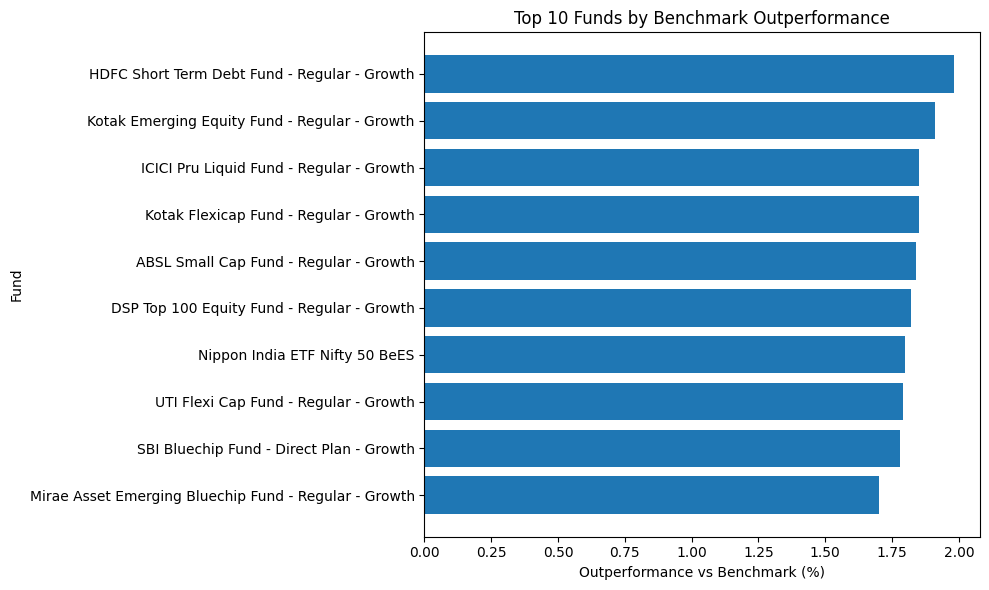

In [48]:
import matplotlib.pyplot as plt

top10 = benchmark_analysis.sort_values(
    'benchmark_difference_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['scheme_name'],
    top10['benchmark_difference_pct']
)

plt.xlabel("Outperformance vs Benchmark (%)")
plt.ylabel("Fund")
plt.title("Top 10 Funds by Benchmark Outperformance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
benchmark_analysis.to_csv(
    "../data/processed/fund_benchmark_analysis.csv",
    index=False
)

print("Task 9 data saved successfully.")

Task 9 data saved successfully.


## Task 9: Fund Performance vs Benchmark

The 3-year performance of all 40 mutual fund schemes was compared with their respective benchmark returns.

All 40 funds outperformed their benchmarks. The average outperformance was 1.25%, with the difference ranging from 0.51% to 1.98%.

HDFC Short Term Debt Fund - Regular - Growth recorded the highest benchmark outperformance of 1.98%, followed by Kotak Emerging Equity Fund - Regular - Growth at 1.91%.

The benchmark comparison data was saved as `fund_benchmark_analysis.csv`.

## Task 10: Fund Performance Summary Dashboard

In [50]:
import pandas as pd

performance = pd.read_csv(
    "../data/processed/09_scheme_performance.csv"
)

ranking = pd.read_csv(
    "../data/processed/fund_risk_adjusted_ranking.csv"
)

benchmark = pd.read_csv(
    "../data/processed/fund_benchmark_analysis.csv"
)

print("Performance:", performance.shape)
print("Ranking:", ranking.shape)
print("Benchmark:", benchmark.shape)

Performance: (40, 19)
Ranking: (40, 29)
Benchmark: (40, 31)


In [51]:
summary = performance[
    [
        'amfi_code',
        'scheme_name',
        'fund_house',
        'category',
        'plan',
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'sharpe_ratio',
        'sortino_ratio',
        'alpha',
        'beta',
        'std_dev_ann_pct',
        'max_drawdown_pct',
        'expense_ratio_pct',
        'risk_grade'
    ]
].copy()

summary.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio,sortino_ratio,alpha,beta,std_dev_ann_pct,max_drawdown_pct,expense_ratio_pct,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,0.88,1.29,0.87,0.89,14.0,-21.70,1.54,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,0.81,1.29,1.78,0.87,14.0,-24.43,0.66,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,0.94,1.35,1.23,0.89,25.0,-13.35,1.43,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,0.93,1.67,1.13,1.04,25.0,-24.78,0.72,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,1.52,2.11,1.60,0.22,4.0,-2.30,0.77,Low


In [52]:
summary = summary.merge(
    benchmark[
        [
            'amfi_code',
            'benchmark_3yr_pct',
            'benchmark_difference_pct',
            'benchmark_status'
        ]
    ],
    on='amfi_code',
    how='left'
)

summary.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio,sortino_ratio,alpha,beta,std_dev_ann_pct,max_drawdown_pct,expense_ratio_pct,risk_grade,benchmark_3yr_pct,benchmark_difference_pct,benchmark_status
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,0.88,1.29,0.87,0.89,14.0,-21.70,1.54,Moderate,11.49,0.87,Outperforming
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,0.81,1.29,1.78,0.87,14.0,-24.43,0.66,Moderate,9.52,1.78,Outperforming
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,0.94,1.35,1.23,0.89,25.0,-13.35,1.43,Very High,22.16,1.23,Outperforming
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,0.93,1.67,1.13,1.04,25.0,-24.78,0.72,Very High,22.01,1.13,Outperforming
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,1.52,2.11,1.60,0.22,4.0,-2.30,0.77,Low,4.47,1.60,Outperforming


In [53]:
total_funds = summary['amfi_code'].nunique()

avg_3yr_return = summary['return_3yr_pct'].mean()

avg_sharpe = summary['sharpe_ratio'].mean()

avg_outperformance = summary['benchmark_difference_pct'].mean()

outperforming_funds = (
    summary['benchmark_status'] == 'Outperforming'
).sum()

print("Total Funds:", total_funds)
print(f"Average 3-Year Return: {avg_3yr_return:.2f}%")
print(f"Average Sharpe Ratio: {avg_sharpe:.2f}")
print(f"Average Benchmark Outperformance: {avg_outperformance:.2f}%")
print("Funds Outperforming Benchmark:", outperforming_funds)

Total Funds: 40
Average 3-Year Return: 14.09%
Average Sharpe Ratio: 1.36
Average Benchmark Outperformance: 1.25%
Funds Outperforming Benchmark: 40


In [54]:
best_return = summary.loc[
    summary['return_3yr_pct'].idxmax(),
    ['scheme_name', 'return_3yr_pct']
]

best_sharpe = summary.loc[
    summary['sharpe_ratio'].idxmax(),
    ['scheme_name', 'sharpe_ratio']
]

best_alpha = summary.loc[
    summary['alpha'].idxmax(),
    ['scheme_name', 'alpha']
]

best_outperformance = summary.loc[
    summary['benchmark_difference_pct'].idxmax(),
    ['scheme_name', 'benchmark_difference_pct']
]

print("Highest 3-Year Return:")
print(best_return)

print("\nHighest Sharpe Ratio:")
print(best_sharpe)

print("\nHighest Alpha:")
print(best_alpha)

print("\nHighest Benchmark Outperformance:")
print(best_outperformance)

Highest 3-Year Return:
scheme_name       SBI Small Cap Fund - Regular Plan - Growth
return_3yr_pct                                         23.39
Name: 2, dtype: object

Highest Sharpe Ratio:
scheme_name     ICICI Pru Liquid Fund - Regular - Growth
sharpe_ratio                                        7.68
Name: 14, dtype: object

Highest Alpha:
scheme_name    HDFC Short Term Debt Fund - Regular - Growth
alpha                                                  1.98
Name: 9, dtype: object

Highest Benchmark Outperformance:
scheme_name                 HDFC Short Term Debt Fund - Regular - Growth
benchmark_difference_pct                                            1.98
Name: 9, dtype: object


In [55]:
summary.to_csv(
    "../data/processed/final_fund_summary.csv",
    index=False
)

print("Final fund summary saved successfully.")

Final fund summary saved successfully.


## Task 10: Fund Performance Summary

The final analysis covered 40 mutual fund schemes across different categories and risk levels.

Key findings:

- Average 3-year return across the funds was 14.09%.
- Average Sharpe ratio was 1.36.
- All 40 funds outperformed their respective 3-year benchmarks.
- Average benchmark outperformance was 1.25%.
- SBI Small Cap Fund - Regular Plan - Growth recorded the highest 3-year return at 23.39%.
- ICICI Pru Liquid Fund - Regular - Growth recorded the highest Sharpe ratio at 7.68.
- HDFC Short Term Debt Fund - Regular - Growth recorded the highest alpha and benchmark outperformance at 1.98%.

The final consolidated fund summary was saved as `final_fund_summary.csv`.

In [56]:
summary.shape

(40, 19)

In [57]:
summary.to_csv(
    "../data/processed/final_fund_summary.csv",
    index=False
)

## Advanced Insights

### 1. Fund Risk and VaR
The Historical VaR analysis shows the potential downside risk across the 40 mutual fund schemes. Funds with more negative VaR values have greater exposure to daily losses. Equity-oriented funds generally show higher downside risk compared with low-volatility debt and liquid funds.

### 2. Rolling Sharpe Ratio
The 90-day rolling Sharpe analysis shows that risk-adjusted performance changes over time. Some funds maintain relatively stable Sharpe ratios, while others experience periods of improvement or deterioration depending on market conditions.

### 3. Investor Cohort Behaviour
Investor cohorts show differences in investment behaviour based on their first transaction year. Later cohorts generally reflect changes in SIP participation and investment amounts as mutual fund adoption increased.

### 4. SIP Continuity
The SIP continuity analysis identifies investors with gaps longer than 35 days between transactions as at-risk investors. These investors may require additional engagement to maintain regular SIP investing behaviour.

### 5. Sector Concentration and Fund Selection
The Sector HHI analysis shows that most funds have moderate sector concentration. A lower HHI indicates better sector diversification, while a higher HHI indicates greater dependence on a smaller number of sectors. Combining HHI with returns and risk-adjusted metrics provides a better basis for comparing funds.